In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

RANDOM_STATE = 42
df = pd.read_csv("../data/processed/telco_features.csv")

In [2]:
target = "Churn"
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges", "num_addons"]
binary_features = ["SeniorCitizen", "has_security_support", "auto_pay"]
categorical_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                        'PaperlessBilling', 'PaymentMethod', 'tenure_group']

X = df.drop(columns=target)
y = df[target]

In [3]:
# Split BEFORE fitting anything, stratified on the churn label
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)
print("Churn rate train:", y_train.mean().round(3), "| test:", y_test.mean().round(3))

(5634, 23) (1409, 23)
Churn rate train: 0.265 | test: 0.265


In [4]:
# Preprocessing: scale numerics, one-hot encode categoricals, pass binaries through
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("bin", "passthrough", binary_features),
    ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False),
     categorical_features),
])

# Sanity check only: fit on TRAIN, transform both
Xt_train = preprocessor.fit_transform(X_train)
Xt_test = preprocessor.transform(X_test)
print(Xt_train.shape, Xt_test.shape)

(5634, 33) (1409, 33)


In [5]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [6]:
import time
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=20, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=5, class_weight="balanced",
        n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4, scale_pos_weight=neg / pos,
        eval_metric="logloss", n_jobs=-1, random_state=RANDOM_STATE),
}

pipelines = {name: Pipeline([("prep", clone(preprocessor)), ("model", m)])
             for name, m in models.items()}

# Train every model on the same training data

In [7]:
sample_w = compute_sample_weight("balanced", y_train)  # sklearn's GB has no class_weight

for name, pipe in pipelines.items():
    start = time.time()
    if name == "Gradient Boosting":
        pipe.fit(X_train, y_train, model__sample_weight=sample_w)
    else:
        pipe.fit(X_train, y_train)
    print(f"{name}: trained in {time.time() - start:.1f}s")

Logistic Regression: trained in 0.2s
Decision Tree: trained in 0.2s
Random Forest: trained in 2.0s
Gradient Boosting: trained in 2.7s
XGBoost: trained in 1.7s


In [8]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_evaluate(pipe, use_sample_weight=False):
    """Mean 5-fold CV metrics on the training set, same folds for every model."""
    rows = []
    for tr, va in skf.split(X_train, y_train):
        p = clone(pipe)
        Xtr, Xva = X_train.iloc[tr], X_train.iloc[va]
        ytr, yva = y_train.iloc[tr], y_train.iloc[va]
        if use_sample_weight:
            p.fit(Xtr, ytr, model__sample_weight=compute_sample_weight("balanced", ytr))
        else:
            p.fit(Xtr, ytr)
        pred, proba = p.predict(Xva), p.predict_proba(Xva)[:, 1]
        rows.append({
            "Accuracy": accuracy_score(yva, pred),
            "Precision": precision_score(yva, pred),
            "Recall": recall_score(yva, pred),
            "F1": f1_score(yva, pred),
            "ROC-AUC": roc_auc_score(yva, proba),
        })
    return pd.DataFrame(rows).mean()

In [9]:
# Compare all five models
results = {name: cv_evaluate(pipe, use_sample_weight=(name == "Gradient Boosting"))
           for name, pipe in pipelines.items()}
comparison = pd.DataFrame(results).T.round(3).sort_values("ROC-AUC", ascending=False)
comparison.to_csv("../reports/model_comparison.csv")
comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
Gradient Boosting,0.750,0.519,0.793,0.627,0.847
Logistic Regression,0.748,0.517,0.795,0.626,0.846
Random Forest,0.780,0.565,0.734,0.639,0.846
XGBoost,0.759,0.532,0.783,0.633,0.843
Decision Tree,0.735,0.500,0.788,0.612,0.828


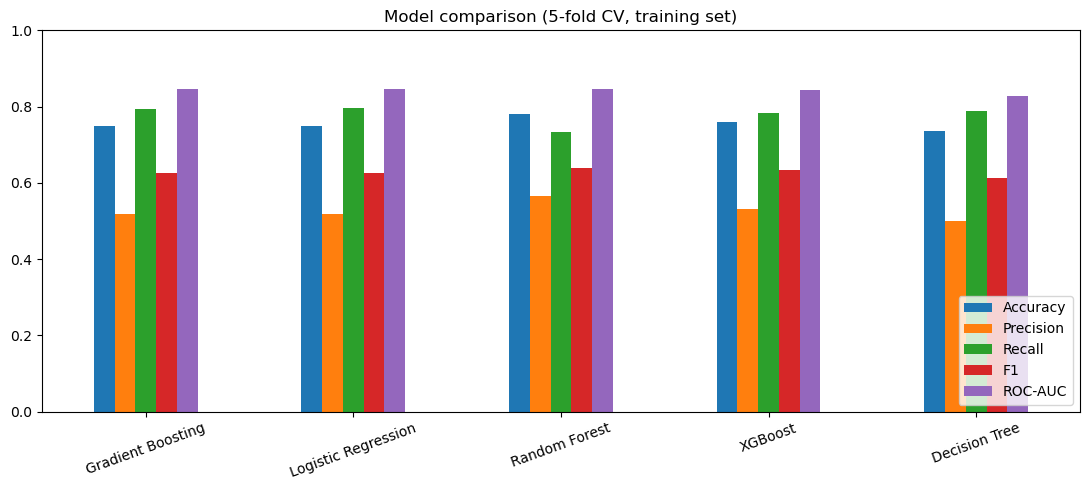

In [10]:
# Visual comparison
comparison.plot(kind="bar", figsize=(11, 5), ylim=(0, 1), rot=20)
plt.title("Model comparison (5-fold CV, training set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../reports/model_comparison.png", dpi=150)
plt.show()

In [11]:
# Effect of class weighting (Logistic Regression) and of removing the depth limit (Decision Tree)
extras = {
    "LogReg (no class weight)": Pipeline([
        ("prep", clone(preprocessor)),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    "Decision Tree (no depth limit)": Pipeline([
        ("prep", clone(preprocessor)),
        ("model", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE))]),
}
extra_results = pd.DataFrame({n: cv_evaluate(p) for n, p in extras.items()}).T.round(3)
pd.concat([comparison.loc[["Logistic Regression", "Decision Tree"]], extra_results])

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.748,0.517,0.795,0.626,0.846
Decision Tree,0.735,0.500,0.788,0.612,0.828
LogReg (no class weight),0.805,0.665,0.538,0.594,0.846
Decision Tree (no depth limit),0.736,0.503,0.492,0.497,0.658


In [12]:
# Overfitting check: unlimited tree, train vs CV recall
deep = extras["Decision Tree (no depth limit)"].fit(X_train, y_train)
print("Train recall:", round(recall_score(y_train, deep.predict(X_train)), 3))
print("CV recall:   ", extra_results.loc["Decision Tree (no depth limit)", "Recall"])

Train recall: 0.999
CV recall:    0.492


In [13]:
import numpy as np
import joblib
from sklearn.model_selection import RandomizedSearchCV, cross_val_predict
from sklearn.metrics import fbeta_score, ConfusionMatrixDisplay

# tuning the three strongest models

In [14]:
search_space = {
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {"n_estimators": [100, 200, 300], "learning_rate": [0.01, 0.03, 0.05, 0.1],
         "max_depth": [2, 3, 4], "subsample": [0.7, 0.85, 1.0],
         "min_samples_leaf": [5, 10, 20]}),
    "XGBoost": (
        XGBClassifier(eval_metric="logloss", n_jobs=1, random_state=RANDOM_STATE),
        {"n_estimators": [200, 300, 500], "learning_rate": [0.01, 0.03, 0.05, 0.1],
         "max_depth": [2, 3, 4, 5], "subsample": [0.7, 0.85, 1.0],
         "colsample_bytree": [0.6, 0.8, 1.0], "min_child_weight": [1, 3, 5],
         "reg_lambda": [1, 5, 10]}),
    "Random Forest": (
        RandomForestClassifier(n_jobs=1, random_state=RANDOM_STATE),
        {"n_estimators": [300, 500], "max_depth": [6, 8, 12, None],
         "min_samples_leaf": [3, 5, 10, 20], "max_features": ["sqrt", 0.5]}),
}

tuned = {}
for name, (est, params) in search_space.items():
    start = time.time()
    pipe = Pipeline([("prep", clone(preprocessor)), ("model", est)])
    search = RandomizedSearchCV(
        pipe, {f"model__{k}": v for k, v in params.items()},
        n_iter=20, scoring="roc_auc", cv=skf, n_jobs=2,
        random_state=RANDOM_STATE, refit=True)
    search.fit(X_train, y_train)
    tuned[name] = search
    print(f"{name}: best CV ROC-AUC {search.best_score_:.4f} ({time.time() - start:.0f}s)")
    print("   ", search.best_params_)

Gradient Boosting: best CV ROC-AUC 0.8499 (243s)
    {'model__subsample': 0.7, 'model__n_estimators': 300, 'model__min_samples_leaf': 20, 'model__max_depth': 2, 'model__learning_rate': 0.05}
XGBoost: best CV ROC-AUC 0.8502 (104s)
    {'model__subsample': 0.85, 'model__reg_lambda': 10, 'model__n_estimators': 200, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.6}
Random Forest: best CV ROC-AUC 0.8481 (343s)
    {'model__n_estimators': 500, 'model__min_samples_leaf': 3, 'model__max_features': 'sqrt', 'model__max_depth': 8}


# Pick the final model (highest CV ROC-AUC)

In [15]:
cv_auc = pd.Series({n: s.best_score_ for n, s in tuned.items()}).sort_values(ascending=False)
print(cv_auc.round(4))
print("Baseline Logistic Regression:", comparison.loc["Logistic Regression", "ROC-AUC"])

best_name = cv_auc.index[0]
final_pipe = tuned[best_name].best_estimator_
print("Final model:", best_name)

XGBoost              0.8502
Gradient Boosting    0.8499
Random Forest        0.8481
dtype: float64
Baseline Logistic Regression: 0.846
Final model: XGBoost


# tune the decision threshold (train data only)

In [16]:
# Out-of-fold probabilities on TRAIN only; the test set is not used for tuning
oof_proba = cross_val_predict(clone(final_pipe), X_train, y_train,
                              cv=skf, method="predict_proba")[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)
f2_scores = [fbeta_score(y_train, oof_proba >= t, beta=2) for t in thresholds]
best_t = round(float(thresholds[int(np.argmax(f2_scores))]), 2)
print("Best threshold (max F2 on train OOF):", best_t)

Best threshold (max F2 on train OOF): 0.17


#  threshold trade-off plot

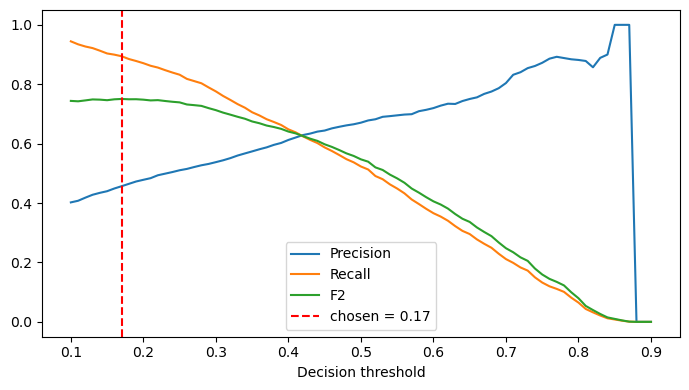

In [17]:
prec = [precision_score(y_train, oof_proba >= t, zero_division=0) for t in thresholds]
rec = [recall_score(y_train, oof_proba >= t) for t in thresholds]

plt.figure(figsize=(7, 4))
plt.plot(thresholds, prec, label="Precision")
plt.plot(thresholds, rec, label="Recall")
plt.plot(thresholds, f2_scores, label="F2")
plt.axvline(best_t, color="red", ls="--", label=f"chosen = {best_t}")
plt.xlabel("Decision threshold")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/threshold_tradeoff.png", dpi=150)
plt.show()

# one evaluation on the test set

In [18]:
test_proba = final_pipe.predict_proba(X_test)[:, 1]

def scores(y_true, proba, t):
    pred = (proba >= t).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred),
        "Recall": recall_score(y_true, pred),
        "F1": f1_score(y_true, pred),
        "ROC-AUC": roc_auc_score(y_true, proba),
    }

test_results = pd.DataFrame({
    "Default threshold 0.50": scores(y_test, test_proba, 0.5),
    f"Tuned threshold {best_t}": scores(y_test, test_proba, best_t),
}).T.round(3)
test_results.to_csv("../reports/final_test_results.csv")
test_results

,Accuracy,Precision,Recall,F1,ROC-AUC
Default threshold 0.50,0.802,0.664,0.513,0.579,0.848
Tuned threshold 0.17,0.681,0.449,0.885,0.596,0.848


# confusion matrix

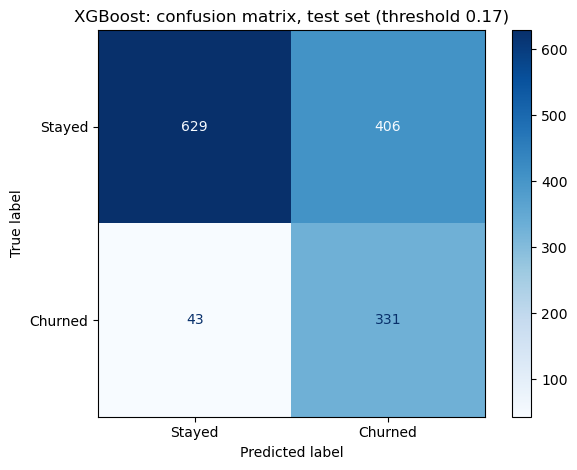

In [19]:
ConfusionMatrixDisplay.from_predictions(
    y_test, (test_proba >= best_t).astype(int),
    display_labels=["Stayed", "Churned"], cmap="Blues")
plt.title(f"{best_name}: confusion matrix, test set (threshold {best_t})")
plt.tight_layout()
plt.savefig("../reports/confusion_matrix.png", dpi=150)
plt.show()

# save the final model

In [20]:
joblib.dump({"pipeline": final_pipe, "threshold": best_t, "model_name": best_name},
            "../models/churn_model.joblib")

['../models/churn_model.joblib']

In [21]:
pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [22]:
import shap

prep = final_pipe.named_steps["prep"]
model = final_pipe.named_steps["model"]
feature_names = [n.split("__", 1)[1] for n in prep.get_feature_names_out()]
X_test_t = pd.DataFrame(prep.transform(X_test), columns=feature_names)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_t)

# Global importance

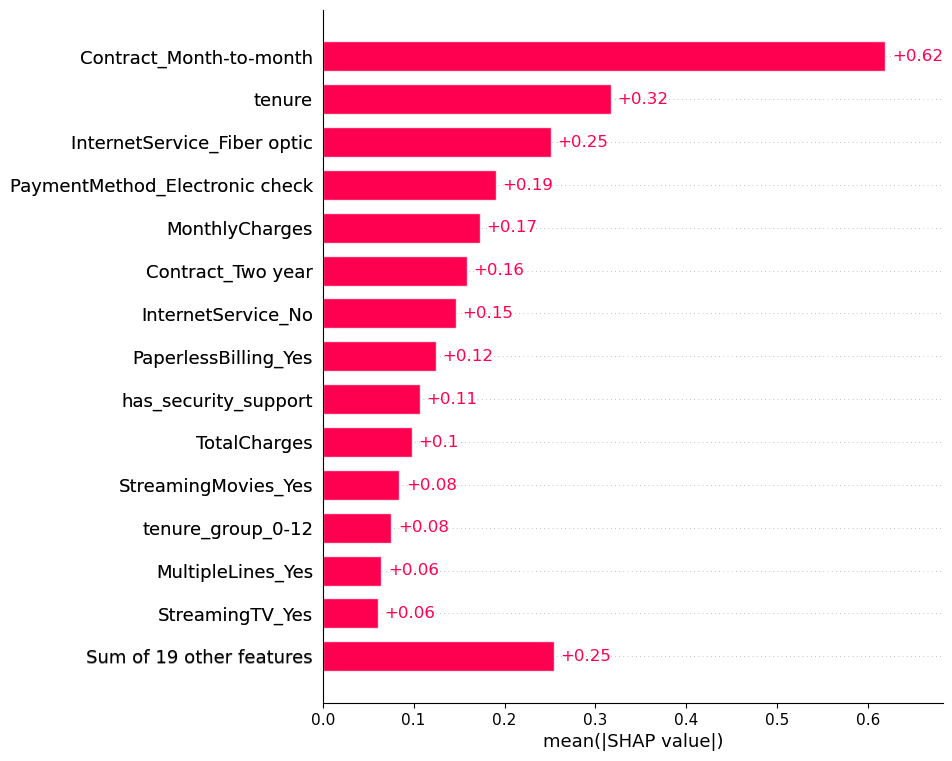

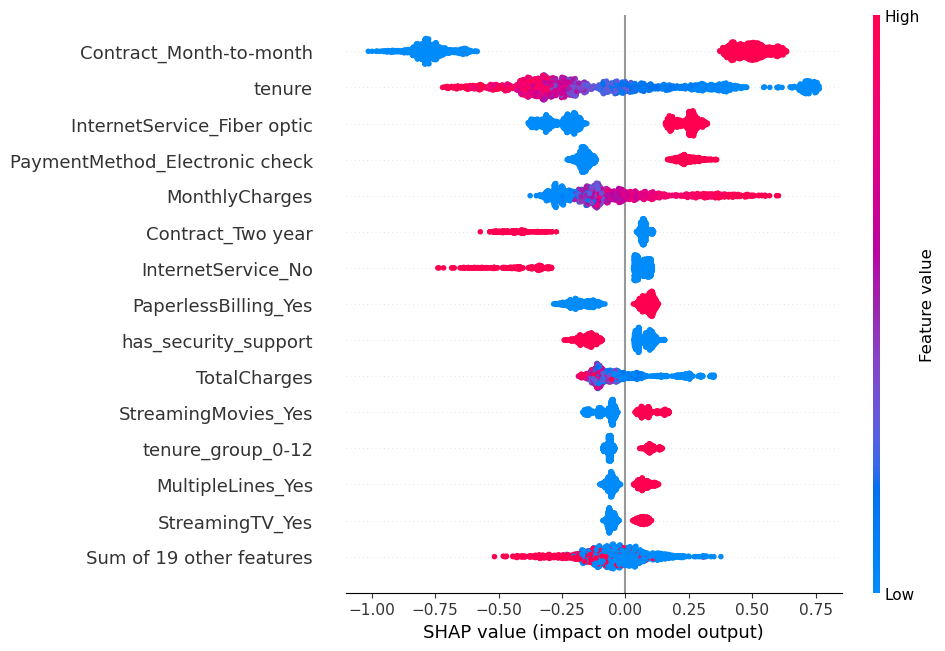

In [23]:
shap.plots.bar(shap_values, max_display=15, show=False)
plt.savefig("../reports/shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Direction and strength of each feature's effect
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.savefig("../reports/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# Explain one individual prediction (the highest-risk customer in the test set)

Churn probability: 0.869


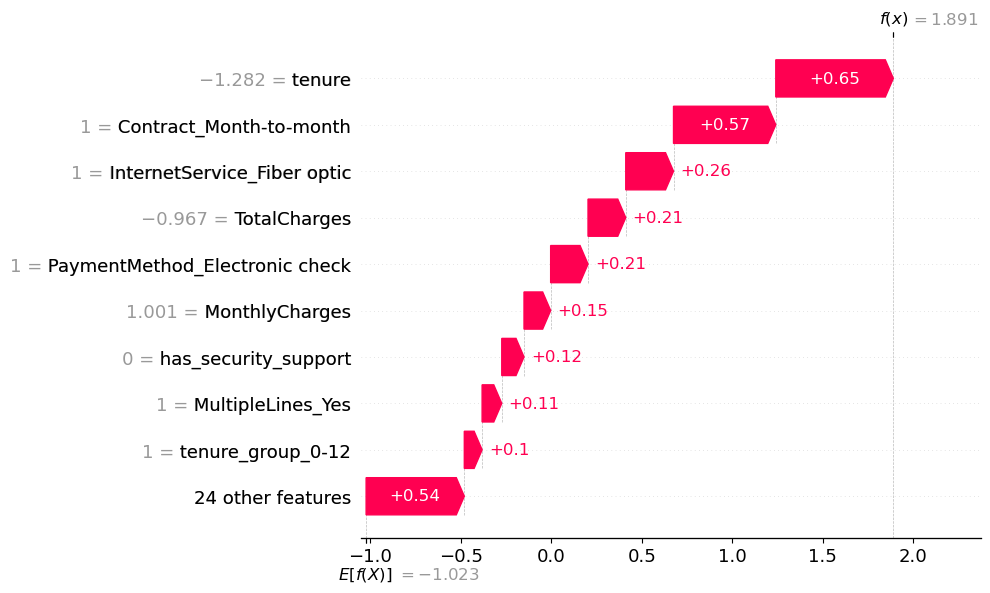

In [24]:
i = int(np.argmax(test_proba))
print("Churn probability:", round(float(test_proba[i]), 3))
shap.plots.waterfall(shap_values[i], max_display=10, show=False)
plt.savefig("../reports/shap_waterfall_customer.png", dpi=150, bbox_inches="tight")
plt.show()

# Top drivers in plain terms

In [26]:
imp = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0),
    "higher value": ["raises churn" if np.corrcoef(X_test_t.iloc[:, j], shap_values.values[:, j])[0, 1] > 0
                     else "lowers churn" for j in range(len(feature_names))],
}).sort_values("mean_abs_shap", ascending=False)
imp.head(10).round(3)

C:\Users\hp\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\hp\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,feature,mean_abs_shap,higher value
21,Contract_Month-to-month,0.619,raises churn
0,tenure,0.317,lowers churn
13,InternetService_Fiber optic,0.251,raises churn
27,PaymentMethod_Electronic check,0.191,raises churn
1,MonthlyCharges,0.173,raises churn
23,Contract_Two year,0.159,lowers churn
14,InternetService_No,0.146,lowers churn
24,PaperlessBilling_Yes,0.125,raises churn
5,has_security_support,0.107,lowers churn
2,TotalCharges,0.098,lowers churn


In [1]:
from importlib.metadata import version

pkgs = ["pandas", "numpy", "scikit-learn", "matplotlib", "seaborn",
        "plotly", "xgboost", "shap", "joblib"]
print("\n".join(f"{p}=={version(p)}" for p in pkgs))

pandas==2.2.3
numpy==2.1.3
scikit-learn==1.6.1
matplotlib==3.10.0
seaborn==0.13.2
plotly==5.24.1
xgboost==3.4.1
shap==0.52.0
joblib==1.4.2
